In [2]:
# %pip install -e .
# %pip install -r requirements.txt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Quick test of the direct-search

<Figure size 1000x600 with 0 Axes>

Running with psstype=1, projection=0, rotation=1, budget=600, simplextype=0

----starting direct-search - budget: 54600 - search dim: 90----
----entering main loop----
it:48, total evals: 5461/54600, loss_per: 4.054e-01, alpha_ds: 1.250e-01, total polls: 4/180
it:96, total evals: 10922/54600, loss_per: 2.551e-01, alpha_ds: 1.250e-01, total polls: 38/180
it:145, total evals: 16383/54600, loss_per: 2.013e-01, alpha_ds: 6.250e-02, total polls: 3/180
it:195, total evals: 21844/54600, loss_per: 1.655e-01, alpha_ds: 6.250e-02, total polls: 71/180
it:243, total evals: 27305/54600, loss_per: 1.436e-01, alpha_ds: 6.250e-02, total polls: 169/180
it:290, total evals: 32766/54600, loss_per: 1.284e-01, alpha_ds: 3.125e-02, total polls: 11/180
it:344, total evals: 38227/54600, loss_per: 1.169e-01, alpha_ds: 3.125e-02, total polls: 6/180
it:397, total evals: 43688/54600, loss_per: 1.081e-01, alpha_ds: 1.562e-02, total polls: 180/180
it:445, total evals: 49149/54600, loss_per: 1.009e-01, alpha_ds: 1.5

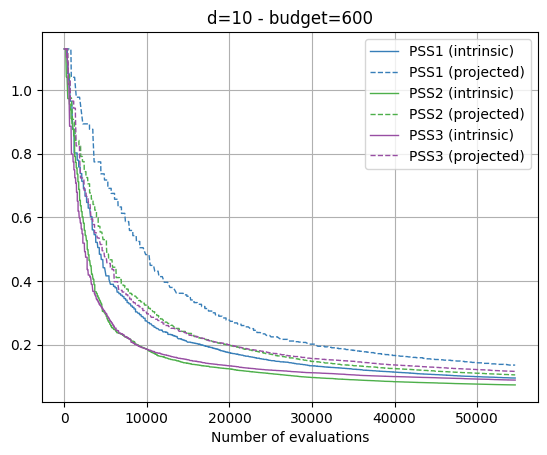

In [6]:
from unittest import result

from ProblemSynchRotations import ProblemSynchRotations
from directsearch import directsearch
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


budget = 600
n = 2
warmstart = 1.
vd = [10]
vinstance = np.arange(0, 1, 1).tolist()
psstypes = [1,2,3]
projections = [0,1]
rotations = [1]
simplextypes = [0] #euclidean


cmapproj = mpl.colormaps["Set1"].colors[1:4]
cmapnoproj = mpl.colormaps["Set1"].colors[1:4]
cmap = [cmapnoproj, cmapproj]
linestyles = ["-", "--"]
linewidths = [2, 1]
variants = ["intrinsic", "projected"]
VF = []
for d in vd:
    plt.figure(figsize=(10, 6))
    plt.show()
    for instance in vinstance:
        problem = ProblemSynchRotations(d=d,n=n, p=1, eps=1e-6, seed=0,warmstart = warmstart)

        for psstype, projection, rotation, simplextype in itertools.product(psstypes, projections, rotations, simplextypes):
            print(f"Running with psstype={psstype}, projection={projection}, rotation={rotation}, budget={budget}, simplextype={simplextype}")
            result_ds = directsearch(
                problem,
                simplexbudget=budget,
                projection=projection,
                psstype=psstype,
                rotation=rotation,
                printing=True)
            res = result_ds
            vf = res["vf"]
            vx = np.cumsum(res["per_iteration_evaluations"])
            cvg = res["stopcriterion"]
            print(f"Convergence criterion: {cvg}")
            # print(vx)
            plt.plot(
            vx,vf,
            color=cmap[projection][psstype - 1],
            linestyle=linestyles[projection],
            linewidth=linewidths[rotation],
            label=f"PSS{psstype} ({variants[projection]})",
            )
            VF.append(vf[-1])
    plt.grid()
    plt.title(f"d={d} - budget={budget}")

    plt.xlabel("Number of evaluations")
    plt.legend()
    print(VF)


<Figure size 1000x600 with 0 Axes>

Running with psstype=1, projection=0, rotation=1, budget=600, simplextype=0

----starting direct-search - budget: 54600 - search dim: 90----
----entering main loop----
it:50, total evals: 5461/54600, loss_per: 5.363e-01, alpha_ds: 5.000e-01, total polls: 56/180
it:97, total evals: 10922/54600, loss_per: 3.265e-01, alpha_ds: 2.500e-01, total polls: 12/180
it:149, total evals: 16383/54600, loss_per: 2.309e-01, alpha_ds: 2.500e-01, total polls: 98/180
it:196, total evals: 21844/54600, loss_per: 1.900e-01, alpha_ds: 1.250e-01, total polls: 11/180
it:248, total evals: 27305/54600, loss_per: 1.544e-01, alpha_ds: 1.250e-01, total polls: 180/180
it:297, total evals: 32766/54600, loss_per: 1.351e-01, alpha_ds: 6.250e-02, total polls: 180/180
it:341, total evals: 38227/54600, loss_per: 1.187e-01, alpha_ds: 6.250e-02, total polls: 30/180
it:387, total evals: 43688/54600, loss_per: 1.050e-01, alpha_ds: 6.250e-02, total polls: 180/180
it:437, total evals: 49149/54600, loss_per: 9.354e-02, alpha_ds:

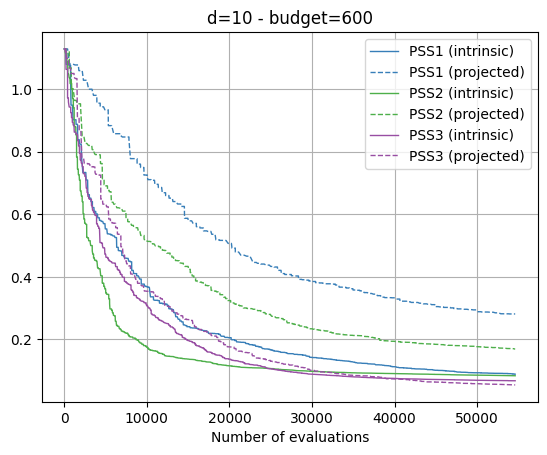

In [9]:
from unittest import result

from ProblemSynchRotations import ProblemSynchRotations
from directsearch import directsearch
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


budget = 600
n = 2
warmstart = 1.
vd = [10]
vinstance = np.arange(0, 1, 1).tolist()
psstypes = [1,2,3]
projections = [0,1]
rotations = [1]
simplextypes = [0] #euclidean


cmapproj = mpl.colormaps["Set1"].colors[1:4]
cmapnoproj = mpl.colormaps["Set1"].colors[1:4]
cmap = [cmapnoproj, cmapproj]
linestyles = ["-", "--"]
linewidths = [2, 1]
variants = ["intrinsic", "projected"]
VF = []
for d in vd:
    plt.figure(figsize=(10, 6))
    plt.show()
    for instance in vinstance:
        problem = ProblemSynchRotations(d=d,n=n, p=1, eps=1e-6, seed=0,warmstart = warmstart)

        for psstype, projection, rotation, simplextype in itertools.product(psstypes, projections, rotations, simplextypes):
            print(f"Running with psstype={psstype}, projection={projection}, rotation={rotation}, budget={budget}, simplextype={simplextype}")
            result_ds = directsearch(
                problem,
                simplexbudget=budget,
                projection=projection,
                psstype=psstype,
                rotation=rotation,
                c = 0.01,
                printing=True)
            res = result_ds
            vf = res["vf"]
            vx = np.cumsum(res["per_iteration_evaluations"])
            cvg = res["stopcriterion"]
            print(f"Convergence criterion: {cvg}")
            # print(vx)
            plt.plot(
            vx,vf,
            color=cmap[projection][psstype - 1],
            linestyle=linestyles[projection],
            linewidth=linewidths[rotation],
            label=f"PSS{psstype} ({variants[projection]})",
            )
            VF.append(vf[-1])
    plt.grid()
    plt.title(f"d={d} - budget={budget}")

    plt.xlabel("Number of evaluations")
    plt.legend()
    print(VF)


Si $b = 100$ et $d = 10$ et $k=2$, alors nous avons que le nombre total d'évaluation vaut:
$e = 100(2d(d-1)/2+1)=100(91)=9100.

In [15]:
from operator import ne
from pathlib import Path
import pandas as pd
root = Path("./experiments/2026-04-17_matrixsizek2_v1/results/")
print(root)
results_accs = []
files = list(root.glob("results_*.pkl")) 
print(f"{len(files)} fichiers trouvés dans {root}")

for file in files:
    print(f"Loading {file}")
    loaded = pd.read_pickle(file)
    results_accs.append(loaded)


print(f"{len(results_accs)} fichiers chargés.")



# for results_acc in results_accs:
#     results_acc["rank"] = results_acc["rank"].apply(lambda x: int(x))
#     results_acc = results_acc.sort_values( by=["model","attack", "rank"],
#     key=lambda col: col.astype(str) if col.name == "attack" else col)

#     # results_acc = results_acc.rename(columns={0: "attack", 1: "accuracy"})
# results_accs_concat = pd.concat(results_accs)

experiments/2026-04-17_matrixsizek2_v1/results
0 fichiers trouvés dans experiments/2026-04-17_matrixsizek2_v1/results
0 fichiers chargés.
